# Turn motion trace — 90° / 180° / 360° as MOVE segments: sim vs bench

Command three **pure in-place turns** — 90°, 180°, 360° CCW — on BOTH the
firmware **simulator** and the **actual robot on the bench**, and overlay the
traces per turn: **heading**, **wheel speed**, and **wheel position** vs time.
Every turn is sent as **one binary `MOVE` segment** (`distance=0`,
`direction=0`, `final_heading=angle`) over the protocol-v3 binary command
plane — the legacy `D`/`T`/`RT` text verbs no longer exist in firmware.

**Where the turn should end** is the horizontal marker at the commanded
angle. The gap between each source's resting trace and that marker is that
plant's terminal error: the sim (calibrated 2026-07-11) lands within ~0.3°;
the real robot currently undershoots ~12% — the open calibration gap tracked
by `clasi/issues/real-robot-motion-calibration-undershoot.md`, and exactly
what this overlay makes visible.

## Sources

`SOURCES` selects what to capture/plot:

- `"sim"` — in-process firmware simulator, tovez-no-cal geometry, every
  noise knob neutral; adds a **ground-truth heading** from the plant. The
  capture cell rebuilds the sim lib and **verifies provenance** (binary
  `VER` vs the workspace version) — a mismatch means this kernel holds a
  stale dylib: **restart the kernel**.
- `"bench"` — the real robot over direct USB, **wheels off the ground on
  the stand** (`.claude/rules/hardware-bench-testing.md`). The port is
  auto-detected from mbdeploy's device registry
  (`transport.find_robot_serial_port()`); the robot's `VER` is printed so a
  stale flash is visible. Heading is encoder-derived (no ground truth).

Both use the identical command + telemetry code: heading =
`(pos_right − pos_left) / trackwidth`; binary telemetry (`ReplyEnvelope{tlm}`)
is drained continuously; `active` (`bb.drivetrain.busy`) marks completion,
sampled `SETTLE_S` past the drop to catch any terminal coast.

## Running it

1. Run all cells. Sources that cannot connect are **skipped with a warning**
   (e.g. robot unplugged → sim-only run).
2. **Close any serial monitor / MakeCode tab holding the robot's port** — the
   bench capture needs exclusive access.
3. Each run caches to `out/turn_trace_<deg>_<source>.csv`. Teardown sends a
   binary `STOP` in a `finally` block — motors are never left running (every
   segment self-terminates anyway).


In [1]:
import math
import pathlib
import sys
import time

import numpy as np
import pandas as pd

# --- Paths: anchored to the repo, never CWD-relative. ---
_here = pathlib.Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "host" / "robot_radio").is_dir()), None)
if REPO is None:
    REPO = pathlib.Path("/Volumes/Proj/proj/RobotProjects/radio-robot-elite")
sys.path.insert(0, str(REPO / "host"))

OUT_DIR = REPO / "tests" / "notebooks" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Session configuration -------------------------------------------------
SOURCES = ["sim", "bench"]         # capture + overlay; drop "bench" for sim-only
PORT = None                        # bench robot; None = auto-detect from the
                                   # device registry (find_robot_serial_port)
MODE = "direct"
TRACKWIDTH = 128.0                 # [mm] data/robots/tovez_nocal.json geometry.trackwidth
STEP = 20                          # [ms] sim tick / bench poll cadence
STREAM_PERIOD = 20                 # [ms] sim binary-telemetry arm (proto floor)
SETTLE_S = 1.0                     # [s] keep sampling this long past active=0
STEP_TIMEOUT_S = 20.0              # [s] per-turn ceiling before "hung"
SPINUP_TICKS = 6                   # grace ticks before an idle frame is trusted
FORCE_RECAPTURE = True             # True re-drives even if cached

# Three pure in-place turns, CCW (+). Each is sent as ONE binary MOVE segment
# (distance=0, direction=0, final_heading=angle) via segment_for_rt() -- the
# legacy RT verb's binary form, NOT a text command.
TURNS = [90.0, 180.0, 360.0]       # [deg]

print(f"repo:    {REPO}")
print(f"cache:   {OUT_DIR}")
print(f"sources: {SOURCES}")
print(f"turns:   {TURNS}  (each a MOVE segment, trackwidth={TRACKWIDTH:.0f}mm)")


repo:    /Volumes/Proj/proj/RobotProjects/radio-robot-elite
cache:   /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/notebooks/out
sources: ['sim', 'bench']
turns:   [90.0, 180.0, 360.0]  (each a MOVE segment, trackwidth=128mm)


In [2]:
# --- Command + capture: one MOVE segment per turn, drain binary TLM --------
# turn_envelope() builds the SAME MotionSegment the firmware executes for a
# MOVE: distance=0, direction=0, final_heading=angle (a pure in-place pivot).
# Heading is derived from the wheels -- (pos_r - pos_l)/trackwidth -- so it
# needs no pose estimator (fused `pose` is 0 pre-098; encpose is trimmed off
# binary TLM). The sim path additionally samples the plant's ground-truth
# heading each tick.
from robot_radio.robot import legacy_translate
from robot_radio.robot.pb2 import envelope_pb2


def turn_envelope(angle):  # [deg]
    """One pure in-place turn as a binary MOVE segment (`segment` arm)."""
    seg = legacy_translate.segment_for_rt(angle * 100.0)   # [cdeg] -> rad inside
    return envelope_pb2.CommandEnvelope(segment=seg)


def stop_envelope():
    env = envelope_pb2.CommandEnvelope()
    env.stop.SetInParent()
    return env


def ver_envelope():
    env = envelope_pb2.CommandEnvelope()
    env.ver.SetInParent()
    return env


def _row(tlm, base, t):
    """One RAW pb2 Telemetry frame -> a plot row.

    Reads the pb2 message directly, NOT TLMFrame: the wire carries enc/vel
    as floats at the firmware's full 0.1mm/0.1mm-s resolution (TLMFrame
    int-truncates them -- fine for control logic, fake staircase for
    plotting), plus each wheel's OWN sample instant (ts_left/ts_right,
    bb.motors[i].sampled_at) and the loop-pass commit instant (now). The
    Nezha flip-flop refreshes each wheel's encoder only every few loop
    passes while telemetry frames ship every ~20ms, so MOST frames repeat a
    stale reading -- the stamps are what let the plot place each reading at
    its TRUE time instead of arrival time (which renders staircases that do
    not exist at the wheel). cmd_l/cmd_r is the COMMANDED per-wheel velocity
    (the PID setpoint), committed at `now`."""
    pos_l = tlm.enc_left - base[0]   # [mm] float, 0.1mm resolution
    pos_r = tlm.enc_right - base[1]  # [mm]
    return {"t": t, "pos_l": pos_l, "pos_r": pos_r,
            "vel_l": tlm.vel_left, "vel_r": tlm.vel_right,
            "cmd_l": tlm.cmd_vel_left, "cmd_r": tlm.cmd_vel_right,
            "ts_l": int(tlm.ts_left), "ts_r": int(tlm.ts_right),   # [ms] fw clock
            "now_fw": int(tlm.now),                                # [ms] fw clock
            "heading_enc": math.degrees((pos_r - pos_l) / TRACKWIDTH),
            "active": int(tlm.active)}


def _finalize(rows):
    """df + done_t, where done_t is the firmware's OWN segment-complete
    signal: the `active` (bb.drivetrain.busy) flag's 1->0 edge -- the first
    idle frame after the busy period. The objective moment the executor
    declares the turn finished (and where a chained tour fires its next
    leg, inheriting whatever heading this one landed at)."""
    df = pd.DataFrame(rows)
    done_t = None
    if not df.empty and (df["active"] == 1).to_numpy().any():
        busy = df["active"].to_numpy() == 1
        last_busy = int(np.where(busy)[0][-1])
        idx = last_busy + 1 if last_busy + 1 < len(df) else last_busy
        done_t = float(df["t"].iloc[idx])
    return df, done_t


def settle_t(df):
    """Physical end of motion: after the speed peak, the first frame where
    both wheels drop below kSettleSpeed. Marked lighter than done_t so any
    terminal-dwell gap (settle_t -> done_t) reads as dwell, not slow motion."""
    if df is None or df.empty:
        return None
    kSettleSpeed = 3.0  # [mm/s]
    speed = df[["vel_l", "vel_r"]].abs().max(axis=1).to_numpy()
    peak_i = int(np.argmax(speed))
    stopped = np.where((speed < kSettleSpeed) & (np.arange(len(df)) > peak_i))[0]
    return float(df["t"].iloc[int(stopped[0])]) if len(stopped) else None


def heading_cmd(df):
    """COMMANDED heading: the time-integral of the commanded differential,
    (cmd_r - cmd_l)/trackwidth, trapezoid rule over the frame times. The
    discriminator between "the plan is wrong" (this lands off-target) and
    "the tracking is wrong" (this lands on-target but the wheels don't)."""
    if df is None or df.empty or "cmd_l" not in df.columns:
        return None
    omega = (df["cmd_r"] - df["cmd_l"]).to_numpy() / TRACKWIDTH   # [rad/s]
    t = df["t"].to_numpy()
    h = np.zeros(len(df))
    h[1:] = np.cumsum(0.5 * (omega[1:] + omega[:-1]) * np.diff(t))
    return np.degrees(h)


def ts_origin(df):
    """The run's firmware-clock origin: earliest nonzero per-wheel stamp."""
    cands = [df[c][df[c] > 0].min() for c in ("ts_l", "ts_r")
             if c in df.columns and (df[c] > 0).any()]
    return float(min(cands)) if cands else None


def wheel_series(df, val_col, ts_col):
    """One channel's (t, value) at its TRUE firmware sample times.

    Keeps only rows where this channel's own stamp ADVANCED (a fresh
    hardware sample; stale telemetry repeats dropped -- ~80% of frames just
    re-ship the previous reading, which is what rendered staircases at
    arrival time), x = seconds since the run's firmware-clock origin. NOT
    smoothing: no reading is altered or averaged, each is simply placed at
    the instant the firmware actually sampled it. Falls back to host
    arrival time when the source carries no stamps."""
    ts0 = ts_origin(df)
    if ts0 is None or ts_col not in df.columns or not (df[ts_col] > 0).any():
        return df["t"], df[val_col]
    d = df[df[ts_col] > 0]
    fresh = d[ts_col].diff().fillna(1.0) != 0
    d = d[fresh]
    return (d[ts_col] - ts0) / 1000.0, d[val_col]


def frame_series(df, val_col):
    """A whole-frame channel (heading, cmd) at the loop-pass COMMIT instant
    (now_fw) -- the one stamp that covers a cross-wheel quantity -- keeping
    only frames where at least one wheel stamp advanced (a frame with two
    stale wheels adds no information). Same fallback as wheel_series()."""
    ts0 = ts_origin(df)
    if ts0 is None or "now_fw" not in df.columns or not (df["now_fw"] > 0).any():
        return df["t"], df[val_col]
    d = df[df["now_fw"] > 0]
    fresh = (d["ts_l"].diff().fillna(1.0) != 0) | (d["ts_r"].diff().fillna(1.0) != 0)
    d = d[fresh]
    return (d["now_fw"] - ts0) / 1000.0, d[val_col]


def done_fw_time(df, done_t):
    """Map the host-time busy->idle instant onto the firmware axis."""
    ts0 = ts_origin(df)
    if done_t is None or ts0 is None or "now_fw" not in df.columns:
        return done_t
    row = df[df["t"] >= done_t]
    if row.empty or int(row["now_fw"].iloc[0]) <= 0:
        return None
    return (float(row["now_fw"].iloc[0]) - ts0) / 1000.0


def capture_sim(conn, proto, angle):
    """Drive one turn in the sim; tick + drain until active=0 (+ SETTLE_S).
    Adds a ground-truth heading column (unwrapped past +/-180)."""
    from robot_radio.testgui import binary_bridge
    conn.set_true_pose(0.0, 0.0, 0.0)                          # fresh start
    binary_bridge.translate_command(proto, f"STREAM {STREAM_PERIOD}")
    conn.drain_binary_tlm()
    reply = conn.send_envelope(turn_envelope(angle))
    body = reply.WhichOneof("body") if reply is not None else None
    if body != "ok":
        raise RuntimeError(f"{angle:.0f}deg segment rejected: body={body}")

    rows, base, t = [], None, 0.0
    prev_h, unwrap = None, 0
    last_active, idle_at = None, None
    settle = int(SETTLE_S * 1000 / STEP)
    for i in range(int(STEP_TIMEOUT_S * 1000 / STEP)):
        conn.tick(STEP)
        t += STEP / 1000.0
        for f in conn.drain_binary_tlm():
            if not f.tlm.has_enc:
                continue
            if base is None:
                base = (f.tlm.enc_left, f.tlm.enc_right)
            r = _row(f.tlm, base, t)
            h = conn.get_true_pose()["h"]                      # [rad], (-pi, pi]
            if prev_h is not None and h - prev_h < -math.pi:
                unwrap += 1
            elif prev_h is not None and h - prev_h > math.pi:
                unwrap -= 1
            prev_h = h
            r["heading_true"] = math.degrees(h + 2 * math.pi * unwrap)
            last_active = bool(f.tlm.active)
            rows.append(r)
        if i >= SPINUP_TICKS and last_active is False:
            idle_at = i if idle_at is None else idle_at
            if i - idle_at >= settle:
                break
        else:
            idle_at = None
    conn.send_envelope(stop_envelope())
    return _finalize(rows)


def capture_bench(conn, angle):
    """Drive one turn on the real robot; poll binary TLM in real time until
    active=0 (+ SETTLE_S). No ground truth -- heading is encoder-derived.

    NO retry on a timed-out reply: binary sends are single-attempt BY
    DESIGN (io/serial_conn.py send_envelope()'s docstring) -- a lost REPLY
    does not mean a lost COMMAND, and re-sending a segment QUEUES A SECOND
    ONE on the firmware's segment ring (observed: a retried 180deg turn
    executed twice, head-to-tail, landing at ~318deg). The encoder baseline
    is taken BEFORE the send, and "the segment never started" (no busy
    frame within the timeout) is the only condition treated as a lost
    command -- reported, not retried."""
    conn.send_envelope(stop_envelope(), read_timeout=300)
    time.sleep(0.8)                                            # let prior coast settle

    # Encoder baseline BEFORE the send, from the continuous stream.
    base = None
    t0 = time.monotonic()
    while time.monotonic() - t0 < 1.0:
        for f in conn.drain_binary_tlm():
            if f.tlm.has_enc:
                base = (f.tlm.enc_left, f.tlm.enc_right)
        if base is not None:
            break
        time.sleep(0.02)
    if base is None:
        raise RuntimeError("no telemetry frames -- stream not armed / link down?")

    rep = conn.send_envelope(turn_envelope(angle), read_timeout=800).get("reply")
    if rep is not None and rep.WhichOneof("body") != "ok":
        raise RuntimeError(f"{angle:.0f}deg segment rejected: {rep}")
    # rep None == reply timeout: proceed; if the command truly never arrived
    # no busy frame will appear and the check below reports it.

    rows = []
    t0 = time.monotonic()
    last_active, idle_since, seen = None, None, False
    while time.monotonic() - t0 < STEP_TIMEOUT_S:
        for f in conn.drain_binary_tlm():
            if not f.tlm.has_enc:
                continue
            r = _row(f.tlm, base, time.monotonic() - t0)
            r["heading_true"] = float("nan")
            last_active = bool(f.tlm.active)
            if last_active:
                seen = True
            rows.append(r)
        if seen and last_active is False:
            idle_since = idle_since or time.monotonic()
            if time.monotonic() - idle_since >= SETTLE_S:
                break
        else:
            idle_since = None
        time.sleep(STEP / 1000.0)
    conn.send_envelope(stop_envelope(), read_timeout=300)
    if not seen:
        # "Never started" must be PROVABLE before anyone retries: under heavy
        # frame loss during fast motion the busy flag can simply never reach
        # us -- but the encoders cannot hide a turn that happened (observed:
        # a lossy 360 with no busy frame seen, retried, double-queued, and
        # the robot turned ~684deg). Movement == it ran; report, don't retry.
        moved = any(abs(r["pos_l"]) > 3.0 or abs(r["pos_r"]) > 3.0 for r in rows)
        if moved:
            raise RuntimeError(
                f"{angle:.0f}deg: no busy frame seen but the ENCODERS MOVED "
                "(heavy frame loss?) -- NOT safe to retry; re-run manually")
        raise RuntimeError(f"{angle:.0f}deg segment never started (no busy frame, "
                           f"no encoder movement, within {STEP_TIMEOUT_S:.0f}s) "
                           "-- command lost")
    return _finalize(rows)


In [3]:
# --- Drive both plants (once each) and cache every (turn, source) ----------
# Safe teardown per source: STOP in a finally block, so a mid-run exception
# or Ctrl-C never leaves motors live (every segment self-terminates anyway).
# A source that cannot connect (robot unplugged, sim lib missing) is skipped
# with a loud warning rather than failing the whole notebook.

def _cache_path(angle, source):
    return OUT_DIR / f"turn_trace_{int(angle)}_{source}.csv"


def _load_cached(angle, source):
    df = pd.read_csv(_cache_path(angle, source))
    dt = df["done_t"].iloc[0] if "done_t" in df.columns and len(df) else None
    return df, (None if dt is None or pd.isna(dt) else float(dt))


def _store(angle, source, df, done):
    out = df.copy()
    out["done_t"] = done
    out.to_csv(_cache_path(angle, source), index=False)


captures = {}   # (source, angle) -> (df, done_t)

import tomllib
with open(REPO / "pyproject.toml", "rb") as _f:
    WORKSPACE_VERSION = tomllib.load(_f)["project"]["version"]


def _capture_sim_source():
    import subprocess

    from robot_radio.io.sim_conn import SimConnection
    from robot_radio.robot.protocol import NezhaProtocol
    from robot_radio.testgui import sim_prefs

    # Rebuild, then PROVE the loaded firmware is current. The trap a rebuild
    # cannot fix: ctypes caches a loaded dylib per process, so a LONG-LIVED
    # kernel that connected before a rebuild keeps executing the OLD
    # firmware no matter what is on disk. The VER handshake catches exactly
    # that -- on mismatch, RESTART THE KERNEL.
    print("[sim] rebuilding sim lib (just build-sim)...")
    res = subprocess.run(["just", "build-sim"], cwd=REPO, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"just build-sim failed:\n{res.stderr[-2000:]}")

    def _apply_zero_error(conn):
        """tovez-no-cal geometry, every noise/scrub knob neutral -- same
        profile->setter mapping transport.py's _apply_profile_to_sim() uses."""
        profile = dict(sim_prefs.DEFAULT_PROFILE)
        profile["trackwidth"] = TRACKWIDTH
        for key, setter in sim_prefs.PROFILE_TO_SIM_SETTER.items():
            getattr(conn, setter)(profile[key])
        conn.set_enc_noise(2, profile["encoder_noise"])
        conn.set_enc_scale_error(0, profile["enc_scale_err_l"])
        conn.set_enc_scale_error(1, profile["enc_scale_err_r"])

    conn = SimConnection(tick_step=STEP)
    assert "error" not in conn.connect(), "sim connect failed"
    reply = conn.send_envelope(ver_envelope())
    fw = reply.id.fw_version if reply is not None and reply.WhichOneof("body") == "id" else "?"
    print(f"[sim] firmware: v{fw}   workspace: v{WORKSPACE_VERSION}")
    if fw != WORKSPACE_VERSION:
        raise RuntimeError(
            f"STALE SIM: this kernel holds firmware v{fw} but the workspace is "
            f"v{WORKSPACE_VERSION}. ctypes cannot reload a dylib in-process -- "
            "RESTART THE KERNEL and re-run."
        )
    _apply_zero_error(conn)
    proto = NezhaProtocol(conn)
    try:
        for a in TURNS:
            df, done = capture_sim(conn, proto, a)
            _store(a, "sim", df, done)
            captures[("sim", a)] = (df, done)
            fin = df["heading_true"].iloc[-1] if len(df) else float("nan")
            print(f"[sim]   {a:6.0f}deg: {len(df):3d} frames  final(truth)={fin:7.2f}deg"
                  f"  err={fin - a:+.2f}deg")
    finally:
        try:
            conn.send_envelope(stop_envelope())
        finally:
            conn.disconnect()
            print("[sim] STOP sent; sim closed")


def _capture_bench_source():
    from robot_radio.io.serial_conn import SerialConnection
    from robot_radio.testgui.transport import find_robot_serial_port

    port = PORT or find_robot_serial_port()
    if port is None:
        raise RuntimeError("no robot serial port found (robot unplugged? "
                           "`mbdeploy probe` refreshes the registry)")
    print(f"[bench] robot port: {port}")

    conn = SerialConnection(port=port, mode=MODE)
    info = conn.connect(skip_ping=False)
    if not conn.is_open:
        raise RuntimeError(f"connect failed -- serial monitor holding the port? {info}")
    try:
        reply = None
        for _ in range(3):   # VER is read-only/idempotent -- safe to retry
            reply = conn.send_envelope(ver_envelope(), read_timeout=800).get("reply")
            if reply is not None:
                break
            time.sleep(0.3)
        fw = reply.id.fw_version if reply is not None and reply.WhichOneof("body") == "id" else "?"
        marker = "" if fw == WORKSPACE_VERSION else "  <-- LAGS WORKSPACE (reflash?)"
        print(f"[bench] firmware: v{fw}   workspace: v{WORKSPACE_VERSION}{marker}")

        # Arm the continuous binary telemetry stream once for the session.
        from robot_radio.robot.protocol import NezhaProtocol
        NezhaProtocol(conn).stream(STREAM_PERIOD)
        time.sleep(0.3)

        for a in TURNS:
            # ONE retry, and only for capture_bench's provably-safe failures:
            # "rejected" (firmware refused) and "never started" (no busy
            # frame AND no encoder movement => the command demonstrably never
            # executed). A timed-out REPLY with motion started is handled
            # inside capture_bench; a lossy run where the encoders moved is
            # NOT retried (re-sending would queue a second segment).
            try:
                df, done = capture_bench(conn, a)
            except RuntimeError as exc:
                if "NOT safe to retry" in str(exc):
                    raise
                print(f"[bench] {a:6.0f}deg: {exc} -- one safe retry")
                time.sleep(1.0)
                df, done = capture_bench(conn, a)
            _store(a, "bench", df, done)
            captures[("bench", a)] = (df, done)
            fin = df["heading_enc"].iloc[-1] if len(df) else float("nan")
            print(f"[bench] {a:6.0f}deg: {len(df):3d} frames  final(enc)={fin:7.2f}deg"
                  f"  err={fin - a:+.2f}deg")
            time.sleep(1.0)                    # settle between turns
    finally:
        try:
            conn.send_envelope(stop_envelope(), read_timeout=300)
        except Exception as exc:                              # noqa: BLE001
            print(f"[bench] WARN STOP on teardown: {exc}")
        if conn.is_open:
            conn.disconnect()
        print("[bench] STOP sent; serial closed")


for _source in SOURCES:
    cached = all(_cache_path(a, _source).exists() for a in TURNS)
    if cached and not FORCE_RECAPTURE:
        for a in TURNS:
            captures[(_source, a)] = _load_cached(a, _source)
        print(f"[{_source}] all turns cached -- skipping "
              "(FORCE_RECAPTURE=True to re-drive)")
        continue
    try:
        if _source == "sim":
            _capture_sim_source()
        else:
            _capture_bench_source()
    except Exception as exc:                                  # noqa: BLE001
        print(f"[WARN] {_source} capture skipped: {exc}")


[sim] rebuilding sim lib (just build-sim)...


[sim] firmware: v0.20260711.6   workspace: v0.20260711.6
[sim]       90deg:  93 frames  final(truth)=  89.74deg  err=-0.26deg
[sim]      180deg: 102 frames  final(truth)= 179.91deg  err=-0.09deg
[sim]      360deg: 128 frames  final(truth)= 360.18deg  err=+0.18deg
[sim] STOP sent; sim closed
[bench] robot port: /dev/cu.usbmodem2121102
[bench] firmware: v0.20260711.6   workspace: v0.20260711.6


[bench]     90deg: 105 frames  final(enc)=  79.42deg  err=-10.58deg


[bench]    180deg: 119 frames  final(enc)= 177.79deg  err=-2.21deg


[bench]    360deg: 137 frames  final(enc)= 351.05deg  err=-8.95deg


[bench] STOP sent; serial closed


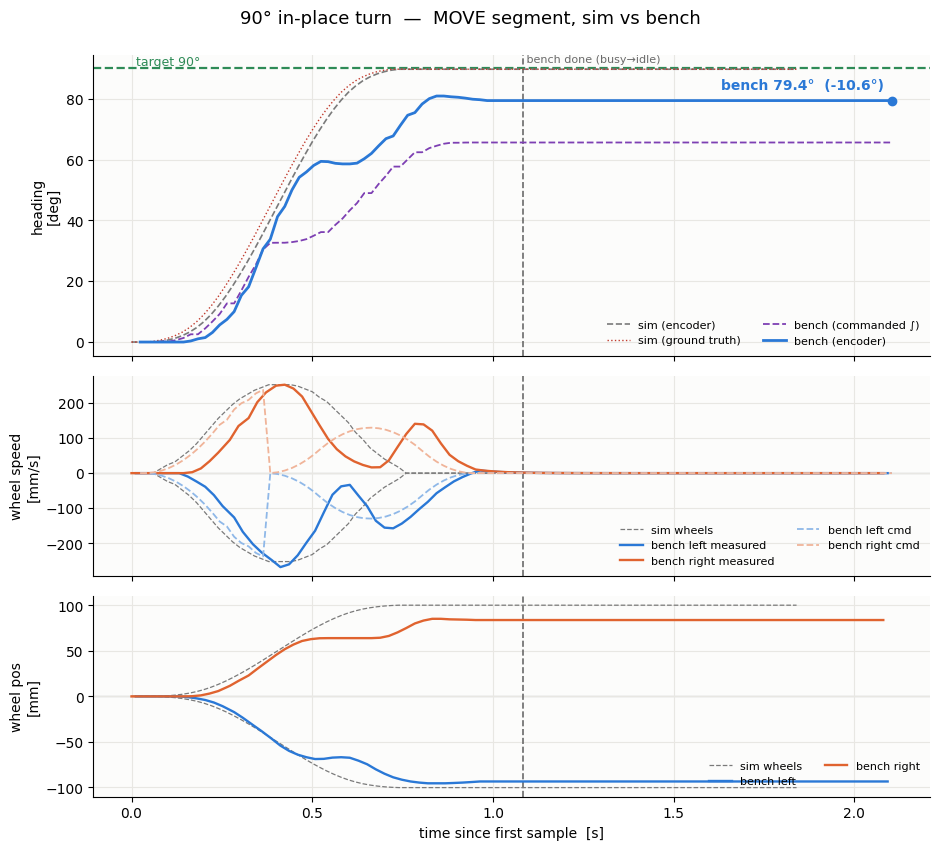

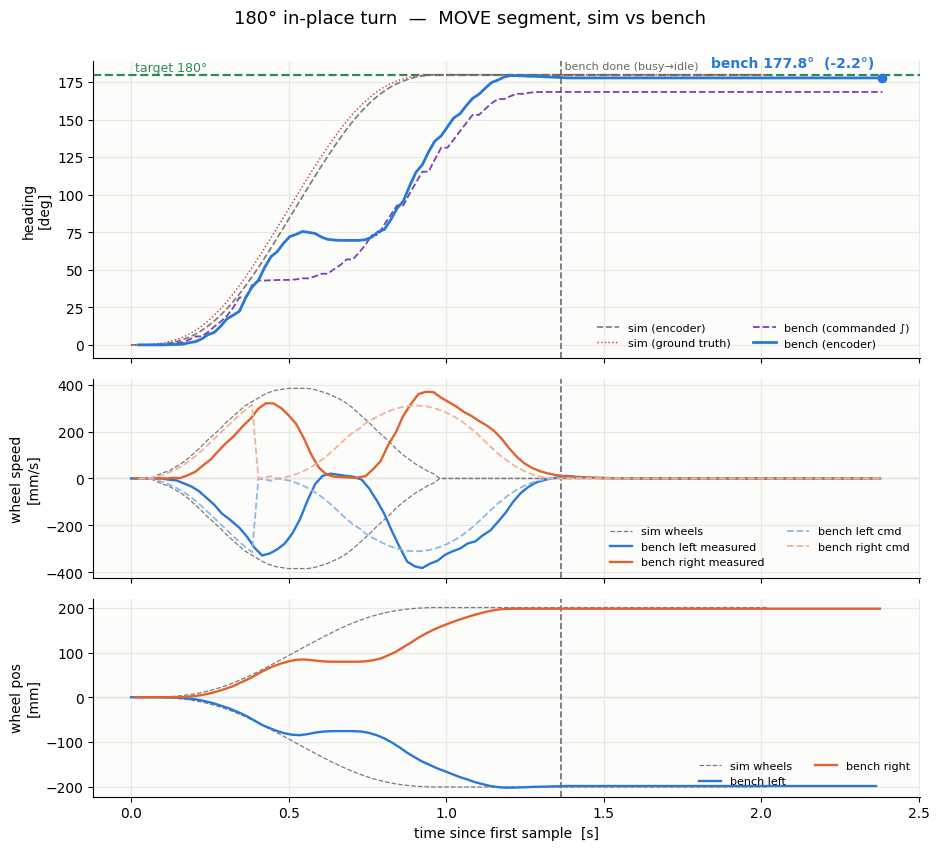

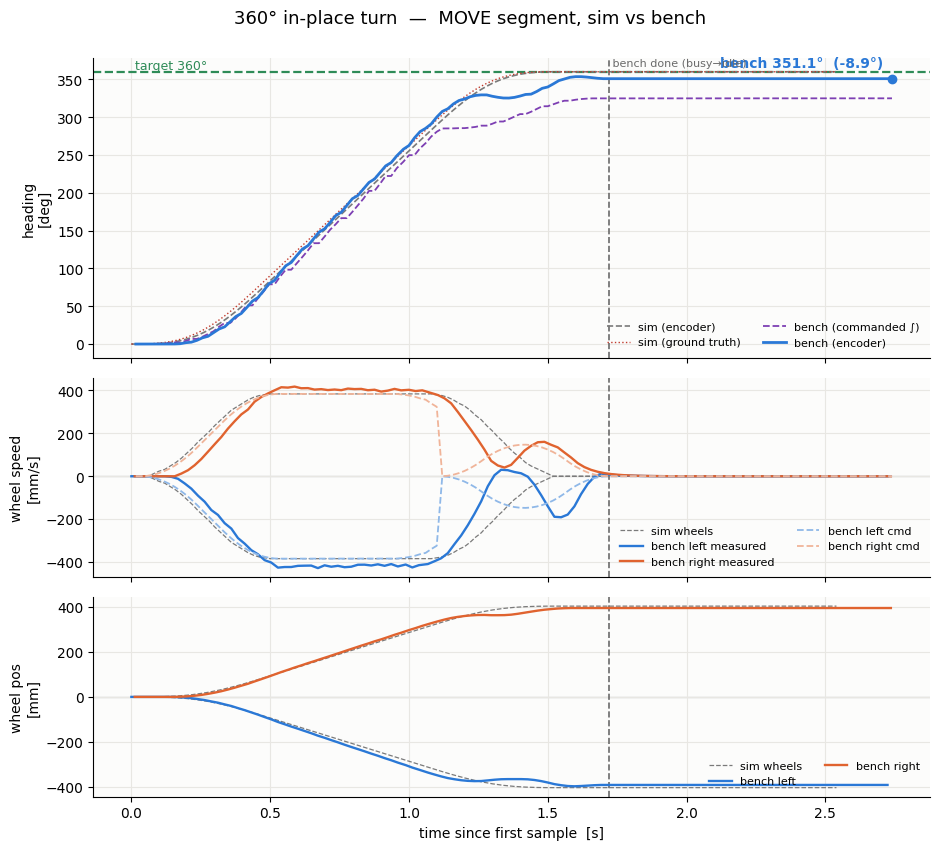

In [4]:
# --- Chart: per turn, sim and bench OVERLAID -------------------------------
# One figure per turn angle. The heading panel carries the commanded-angle
# target line plus, per source: encoder-derived heading (solid = bench,
# dashed = sim), the sim's plant ground truth (dotted), and the bench's
# commanded-integral (the executor's own plan -- if IT misses the target,
# the plan is wrong; if it hits and the wheels don't, tracking is wrong:
# on current hardware the gap between bench cmd-integral and bench encoder
# heading IS the ~12% tracking undershoot). Speed/position panels show the
# bench wheels (solid) against the sim's (thin) for shape comparison, and
# the bench commanded setpoints (dashed) against measured.
import matplotlib.pyplot as plt

BENCH_L = "#2a78d6"    # bench left wheel / bench heading
BENCH_R = "#e0632f"    # bench right wheel
BENCH_CL = "#8fb8e8"   # bench left commanded (dashed)
BENCH_CR = "#f0b499"   # bench right commanded (dashed)
SIM = "#7a7a7a"        # sim traces (thin/dashed)
TRUTH = "#c0392b"      # sim ground-truth heading (dotted)
CMD_H = "#7d3fb3"      # bench commanded-integral heading
TARGET = "#2e8b57"     # commanded-angle marker ("should end")
DONE = "#6a6a6a"       # bench busy->idle completion marker


def plot_turn(angle):
    bench = captures.get(("bench", angle), (None, None))
    sim = captures.get(("sim", angle), (None, None))
    df_b, done_b = bench
    df_s, _done_s = sim
    if (df_b is None or df_b.empty) and (df_s is None or df_s.empty):
        print(f"{angle:.0f}deg: no data from either source")
        return

    done_fw = done_fw_time(df_b, done_b) if df_b is not None else None

    fig, (ax_h, ax_v, ax_p) = plt.subplots(
        3, 1, figsize=(9.5, 8.5), sharex=True, facecolor="white",
        gridspec_kw={"height_ratios": [2.4, 1.6, 1.6]})
    fig.suptitle(f"{angle:.0f}° in-place turn  —  MOVE segment, sim vs bench",
                 fontsize=13, y=0.995)
    for ax in (ax_h, ax_v, ax_p):
        ax.set_facecolor("#fcfcfb")
        ax.grid(True, color="#e8e7e3", lw=0.8, zorder=0)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        if done_fw is not None:
            ax.axvline(done_fw, color=DONE, ls="--", lw=1.2, zorder=2)

    # Every measured channel is drawn at its wheel's TRUE firmware sample
    # times, fresh samples only (wheel_series/frame_series -- see their
    # docstrings): what raggedness remains after this is REAL, not
    # telemetry-cadence staircase.

    # 1. heading
    ax_h.axhline(angle, color=TARGET, ls="--", lw=1.6, zorder=2)
    ax_h.text(0.0, angle, f" target {angle:.0f}°", color=TARGET,
              fontsize=9, va="bottom")
    if df_s is not None and not df_s.empty:
        ax_h.plot(*frame_series(df_s, "heading_enc"), color=SIM, lw=1.2,
                  ls="--", label="sim (encoder)")
        if "heading_true" in df_s.columns and df_s["heading_true"].notna().any():
            ax_h.plot(*frame_series(df_s, "heading_true"), color=TRUTH,
                      lw=1.0, ls=":", label="sim (ground truth)")
    if df_b is not None and not df_b.empty:
        h_cmd = heading_cmd(df_b)
        if h_cmd is not None:
            hb = df_b.assign(_hcmd=h_cmd)
            ax_h.plot(*frame_series(hb, "_hcmd"), color=CMD_H, lw=1.3,
                      ls="--", label="bench (commanded ∫)")
        hx, hy = frame_series(df_b, "heading_enc")
        ax_h.plot(hx, hy, color=BENCH_L, lw=2.0, label="bench (encoder)")
        fin = float(hy.iloc[-1])
        ax_h.plot(hx.iloc[-1], fin, "o", color=BENCH_L, ms=6, zorder=4)
        ax_h.annotate(f"bench {fin:.1f}°  ({fin - angle:+.1f}°)",
                      (hx.iloc[-1], fin), textcoords="offset points",
                      xytext=(-6, 8), ha="right", color=BENCH_L,
                      fontsize=10, fontweight="bold")
    ax_h.set_ylabel("heading\n[deg]")

    # 2. wheel speed
    ax_v.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    if df_s is not None and not df_s.empty:
        ax_v.plot(*wheel_series(df_s, "vel_l", "ts_l"), color=SIM, lw=0.9,
                  ls="--", label="sim wheels")
        ax_v.plot(*wheel_series(df_s, "vel_r", "ts_r"), color=SIM, lw=0.9, ls="--")
    if df_b is not None and not df_b.empty:
        ax_v.plot(*wheel_series(df_b, "vel_l", "ts_l"), color=BENCH_L, lw=1.7,
                  label="bench left measured")
        ax_v.plot(*wheel_series(df_b, "vel_r", "ts_r"), color=BENCH_R, lw=1.7,
                  label="bench right measured")
        if "cmd_l" in df_b.columns:
            ax_v.plot(*frame_series(df_b, "cmd_l"), color=BENCH_CL, lw=1.3,
                      ls="--", label="bench left cmd")
            ax_v.plot(*frame_series(df_b, "cmd_r"), color=BENCH_CR, lw=1.3,
                      ls="--", label="bench right cmd")
    ax_v.set_ylabel("wheel speed\n[mm/s]")

    # 3. wheel position
    ax_p.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    if df_s is not None and not df_s.empty:
        ax_p.plot(*wheel_series(df_s, "pos_l", "ts_l"), color=SIM, lw=0.9,
                  ls="--", label="sim wheels")
        ax_p.plot(*wheel_series(df_s, "pos_r", "ts_r"), color=SIM, lw=0.9, ls="--")
    if df_b is not None and not df_b.empty:
        ax_p.plot(*wheel_series(df_b, "pos_l", "ts_l"), color=BENCH_L, lw=1.7,
                  label="bench left")
        ax_p.plot(*wheel_series(df_b, "pos_r", "ts_r"), color=BENCH_R, lw=1.7,
                  label="bench right")
    ax_p.set_ylabel("wheel pos\n[mm]")
    ax_p.set_xlabel("time since first sample  [s]")

    for ax in (ax_h, ax_v, ax_p):
        ax.legend(loc="lower right", frameon=False, fontsize=8, ncol=2)
    if done_fw is not None:
        ax_h.text(done_fw, ax_h.get_ylim()[1], " bench done (busy→idle)",
                  color=DONE, fontsize=8, va="top")
    fig.tight_layout()
    plt.show()


for a in TURNS:
    plot_turn(a)


In [5]:
# --- Summary: per (turn, source) -- target vs plan vs landing ---------------
# cmd_final_deg  = where that source's executor plan integrated to.
# final_deg      = where the wheels actually rested (truth in sim, encoder
#                  on the bench). cmd_final ~= final => tracking faithful,
#                  any miss vs turn_deg is the PLAN's; cmd_final on target
#                  but final short => TRACKING deficit (the real robot's
#                  current ~12% undershoot -- see
#                  clasi/issues/real-robot-motion-calibration-undershoot.md).

def summarize(angle, source):
    df, done_t = captures.get((source, angle), (None, None))
    if df is None or df.empty:
        return {"turn_deg": angle, "source": source, "frames": 0}
    col = ("heading_true" if source == "sim"
           and "heading_true" in df.columns and df["heading_true"].notna().any()
           else "heading_enc")
    final = float(df[col].iloc[-1])
    out = {"turn_deg": angle, "source": source, "frames": len(df),
           "final_deg": round(final, 2),
           "err_deg": round(final - angle, 2),
           "err_pct": round(100.0 * (final - angle) / angle, 1),
           "peak_speed": round(float(df[["vel_l", "vel_r"]].abs().to_numpy().max()), 1)}
    h_cmd = heading_cmd(df)
    if h_cmd is not None:
        out["cmd_final_deg"] = round(float(h_cmd[-1]), 2)
    st = settle_t(df)
    if st is not None and done_t is not None:
        out["dwell_s"] = round(done_t - st, 3)
    return out


pd.DataFrame([summarize(a, s) for a in TURNS for s in SOURCES])


,turn_deg,source,frames,final_deg,err_deg,err_pct,peak_speed,cmd_final_deg,dwell_s
0,90.0,sim,93,89.74,-0.26,-0.3,252.0,89.99,0.080
1,90.0,bench,105,79.42,-10.58,-11.8,267.7,65.64,0.000
2,180.0,sim,102,179.91,-0.09,-0.1,384.0,179.99,0.040
3,180.0,bench,119,177.79,-2.21,-1.2,382.0,168.49,-0.106
4,360.0,sim,128,360.18,0.18,0.0,384.0,359.99,0.020
5,360.0,bench,137,351.05,-8.95,-2.5,428.1,325.06,-0.106
